# Analisis Sentimen Review Produk Elektronik Menggunakan IndoBERT
**Deskripsi Proyek:** Proyek ini bertujuan membangun model Sentiment Analysis pada ulasan produk kategori elektronik menggunakan model IndoBERT (indobenchmark/indobert-base-p1) untuk mengklasifikasikan sentimen menjadi tiga kelas, yaitu positif, netral, dan negatif. Tahapan yang dilakukan meliputi Exploratory Data Analysis (EDA), preprocessing teks tanpa menggunakan Sastrawi, pelabelan menggunakan target asli dataset, tokenisasi, pelatihan model menggunakan class weight, evaluasi performa menggunakan Accuracy, Macro F1, Weighted F1, Error Analysis, Inference, serta penyimpanan model ke format .pkl. Model terbaik menggunakan konfigurasi learning rate 1e-5, batch size 16, epoch 6, dan warmup step 300 dengan hasil Accuracy sebesar 94,49%, Macro F1 sebesar 65,74%, dan Weighted F1 sebesar 94,25%.

# A. Import Library

In [1]:
!pip install pandas numpy scikit-learn transformers torch accelerate matplotlib -q

import pandas as pd
import numpy as np
import re
import os
import ast
import pickle
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import html

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# B. Load Data Scraping

In [2]:
base_path = "/kaggle/input/datasets/adindaintanerlita/sentiment-elektronik/"

df = pd.read_csv(
    base_path + "elektronik.csv"
)

with open(
    base_path + "slangwords.csv",
    "r",
    encoding="utf-8"
) as f:
    slang_dict = ast.literal_eval(f.read())

print(df.head())
print("Jumlah data:", len(df))
print(df.info())
print(df.isnull().sum())

                                                name    category  \
0  TP-LINK TL-SF1024M 24-Port 10/100M TPLINK Swit...  elektronik   
1        Lan Tester Alat Penguji Kabel Lan RJ45 RJ11  elektronik   
2  stik pc / gamepad usb double hitam kualitas super  elektronik   
3                       Kabel HDMI to HDMI 3M Jaring  elektronik   
4  Gamepad single Usb M-Tech/stick laptop/stick p...  elektronik   

                                              review  rating    target  
0                       barang ok , layanan ok trims       5  Positive  
1        Makasih brg dah sampai dgn baik Dan cepat 😊       5  Positive  
2  Ok gan...barangnya udh diterima dg baik..respo...       5  Positive  
3      Fast respon..pesanan sudah ditrima..thnks GAN       5  Positive  
4                  Lumayan lah buat main PES, thanks       4  Positive  
Jumlah data: 10000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column    Non-Null Cou

# C. Exploratory Data Analysis (EDA)

Ukuran dataset: (10000, 5)

Nama kolom:
Index(['name', 'category', 'review', 'rating', 'target'], dtype='object')

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      10000 non-null  object
 1   category  10000 non-null  object
 2   review    10000 non-null  object
 3   rating    10000 non-null  int64 
 4   target    10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB
None

Jumlah missing value:
name        0
category    0
review      0
rating      0
target      0
dtype: int64

Jumlah duplikasi:
0

Distribusi rating:
rating
1     128
2      84
3     425
4    1449
5    7914
Name: count, dtype: int64

Distribusi kategori:
category
elektronik    9955
Elektronik      45
Name: count, dtype: int64

Distribusi target:
target
Positive    9363
Neutral      425
Negative     212
Name: count, dtype: int64

Statistik p

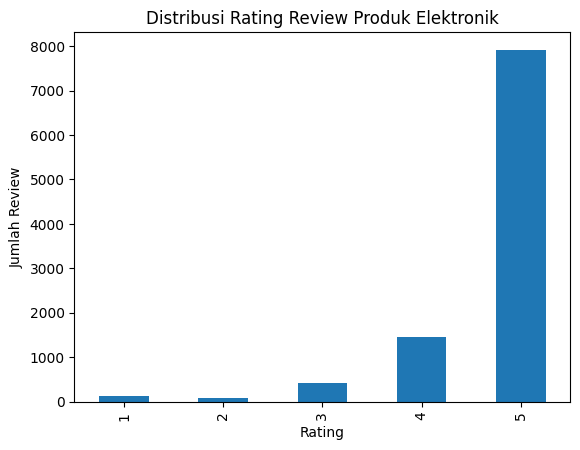

In [3]:
print("Ukuran dataset:", df.shape)
print("\nNama kolom:")
print(df.columns)

print("\nInfo dataset:")
print(df.info())

print("\nJumlah missing value:")
print(df.isnull().sum())

print("\nJumlah duplikasi:")
print(df.duplicated().sum())

print("\nDistribusi rating:")
print(df["rating"].value_counts().sort_index())

print("\nDistribusi kategori:")
print(df["category"].value_counts())

if "target" in df.columns:
    print("\nDistribusi target:")
    print(df["target"].value_counts())

df["review_length"] = df["review"].astype(str).apply(len)
df["word_count"] = df["review"].astype(str).apply(lambda x: len(x.split()))

print("\nStatistik panjang review:")
print(df[["review_length", "word_count"]].describe())

df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribusi Rating Review Produk Elektronik")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.show()

# D. Preprocessing

In [4]:
emoji_dict = {
    "😊": "senang", "😁": "senang", "😍": "suka",
    "🥰": "suka", "😭": "kecewa", "😢": "sedih",
    "😡": "marah", "😤": "kesal", "🤩": "senang",
    "🔥": "bagus", "👍": "bagus", "👎": "jelek",
    "💔": "kecewa", "❤️": "suka", "❤": "suka"
}

def clean_text(text):

    text = str(text).lower()

    text = html.unescape(text)

    text = re.sub(r'\\n|\\t|\\r|\\b|\\f|\\v', ' ', text)
    text = re.sub(r'\\u[0-9a-fA-F]{4}', ' ', text)
    text = re.sub(r'\\x[0-9a-fA-F]{2}', ' ', text)

    text = re.sub(r'http\S+|www\S+', '', text)

    for emo, meaning in emoji_dict.items():
        text = text.replace(emo, " " + meaning + " ")

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    words = text.split()
    words = [slang_dict.get(w, w) for w in words]

    text = " ".join(words)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df = df.dropna(subset=["review"])

df["clean_text"] = df["review"].apply(clean_text)

df = df[df["clean_text"] != ""]

print(df[["review", "clean_text", "rating"]].head())

print("\nKolom dataset:")
print(df.columns)

if "target" in df.columns:
    print("\nDistribusi Target:")
    print(df["target"].value_counts())

                                              review  \
0                       barang ok , layanan ok trims   
1        Makasih brg dah sampai dgn baik Dan cepat 😊   
2  Ok gan...barangnya udh diterima dg baik..respo...   
3      Fast respon..pesanan sudah ditrima..thnks GAN   
4                  Lumayan lah buat main PES, thanks   

                                          clean_text  rating  
0                barang oke layanan oke terima kasih       5  
1  terima kasih barang sudah sampai dengan baik d...       5  
2  oke juragan barangnya udh diterima dg baik res...       5  
3   cepat respon pesanan sudah ditrima thnks juragan       5  
4             lumayan lah buat main pes terima kasih       4  

Kolom dataset:
Index(['name', 'category', 'review', 'rating', 'target', 'review_length',
       'word_count', 'clean_text'],
      dtype='object')

Distribusi Target:
target
Positive    9337
Neutral      422
Negative     212
Name: count, dtype: int64


# E. Labeling

In [5]:
df["sentiment"] = df["target"].str.lower()

df["sentiment"] = df["sentiment"].replace({
    "positive": "positif",
    "neutral": "netral",
    "negative": "negatif"
})

print("Distribusi Sentimen:")
print(df["sentiment"].value_counts())

Distribusi Sentimen:
sentiment
positif    9337
netral      422
negatif     212
Name: count, dtype: int64


# E1. Label Encoding

In [6]:
sentiment_labels = sorted(df["sentiment"].unique())

label_map = {
    label: i
    for i, label in enumerate(sentiment_labels)
}

sentiment_map = {
    v: k
    for k, v in label_map.items()
}

df["label"] = df["sentiment"].map(label_map)

print("Label Map:")
print(label_map)

Label Map:
{'negatif': 0, 'netral': 1, 'positif': 2}


# F. Split Data

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Distribusi Train:")
print(y_train.value_counts())

print("\nDistribusi Test:")
print(y_test.value_counts())

Distribusi Train:
label
2    7469
1     337
0     170
Name: count, dtype: int64

Distribusi Test:
label
2    1868
1      85
0      42
Name: count, dtype: int64


# G. Tokenizer dan Dataset

In [8]:
model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

lengths = df["clean_text"].str.split().apply(len)

max_len = int(
    np.percentile(
        lengths,
        95
    )
)

max_len = min(
    max_len,
    128
)

print(
    "Max Length:",
    max_len
)

train_enc = tokenizer(
    list(X_train),

    truncation=True,
    padding=True,

    max_length=max_len
)

test_enc = tokenizer(
    list(X_test),

    truncation=True,
    padding=True,

    max_length=max_len
)

class SentimentDataset(
    torch.utils.data.Dataset
):

    def __init__(
        self,
        encodings,
        labels
    ):

        self.encodings = encodings

        self.labels = (
            labels.tolist()
        )

    def __getitem__(
        self,
        idx
    ):

        item = {
            k: torch.tensor(v[idx])

            for k, v in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx]
        )

        return item

    def __len__(self):

        return len(
            self.labels
        )

train_dataset = SentimentDataset(
    train_enc,
    y_train
)

test_dataset = SentimentDataset(
    test_enc,
    y_test
)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Max Length: 20


# H. Class Weight

In [9]:
class_weights = compute_class_weight(
    class_weight="balanced",

    classes=np.unique(
        y_train
    ),

    y=y_train
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

print(
    "Class Weights:",
    class_weights
)

Class Weights: tensor([15.6392,  7.8892,  0.3560])


# I. Mertics

In [10]:
def compute_metrics(
    eval_pred
):

    logits, labels = eval_pred

    preds = np.argmax(
        logits,
        axis=1
    )

    return {

        "accuracy":
        accuracy_score(
            labels,
            preds
        ),

        "f1_weighted":
        f1_score(
            labels,
            preds,

            average="weighted"
        ),

        "f1_macro":
        f1_score(
            labels,
            preds,

            average="macro"
        )
    }

# J. Custom Trainer dengan Class Weight

In [11]:
class WeightedTrainer(
    Trainer
):

    def compute_loss(

        self,

        model,

        inputs,

        return_outputs=False,

        num_items_in_batch=None

    ):

        labels = inputs.pop(
            "labels"
        )

        outputs = model(
            **inputs
        )

        logits = (
            outputs.logits

            if hasattr(
                outputs,
                "logits"
            )

            else outputs[0]
        )

        weights = class_weights.to(
            logits.device
        )

        loss_fct = nn.CrossEntropyLoss(
            weight=weights
        )

        num_labels = logits.shape[-1]

        loss = loss_fct(

            logits.view(
                -1,
                num_labels
            ),

            labels.view(-1)
        )

        return (
            (loss, outputs)

            if return_outputs

            else loss
        )

# K. Hyperparameter Tuning & Batch Size¶

In [16]:
training_args = TrainingArguments(

    output_dir=
    "./results_elektronik_best_v2",

    learning_rate=1e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=6,

    eval_strategy="epoch",

    save_strategy="epoch",

    save_total_limit=1,

    load_best_model_at_end=True,

    metric_for_best_model=
    "f1_macro",

    greater_is_better=True,

    logging_steps=100,

    warmup_steps=300,

    weight_decay=0.01,

    fp16=torch.cuda.is_available(),

    report_to="none"
)

trainer = WeightedTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=
    compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

trainer.train()

eval_result = trainer.evaluate()

print(eval_result)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.347076,1.264557,0.913784,0.923193,0.594157
2,0.418464,1.403878,0.935840,0.934668,0.623445
3,0.271538,1.536193,0.943860,0.941610,0.654410
4,0.306600,1.721812,0.944862,0.942488,0.657375
5,0.183118,1.899695,0.939348,0.938893,0.645278
6,0.110698,2.010007,0.946867,0.942162,0.642336


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'eval_loss': 1.7217333316802979, 'eval_accuracy': 0.9448621553884712, 'eval_f1_weighted': 0.9424876348182941, 'eval_f1_macro': 0.6573748224626167, 'eval_runtime': 4.3308, 'eval_samples_per_second': 460.651, 'eval_steps_per_second': 14.547, 'epoch': 6.0}


# L. Evaluasi Model Terbaik

In [17]:
best_model = trainer.model
best_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)

all_preds = []
all_labels = []

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

with torch.no_grad():
    for batch in test_loader:
        labels = batch["labels"].cpu().numpy()

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        outputs = best_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        preds = torch.argmax(
            outputs.logits,
            dim=1
        ).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

print("\nCLASSIFICATION REPORT:")
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(sentiment_labels))),
    target_names=sentiment_labels
))

print("\nCONFUSION MATRIX:")
print(confusion_matrix(y_true, y_pred))

print("\nF1-SCORE PER CLASS:")
f1_per_class = f1_score(
    y_true,
    y_pred,
    average=None
)

for label, score in zip(sentiment_labels, f1_per_class):
    status = "AMAN" if score >= 0.75 else "PERLU DITINGKATKAN"
    print(f"{label:10s}: F1 = {score:.4f} | {status}")

print(f"\nAccuracy   : {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1   : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_true, y_pred, average='weighted'):.4f}")


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     negatif       0.71      0.57      0.63        42
      netral       0.39      0.34      0.36        85
     positif       0.97      0.98      0.98      1868

    accuracy                           0.94      1995
   macro avg       0.69      0.63      0.66      1995
weighted avg       0.94      0.94      0.94      1995


CONFUSION MATRIX:
[[  24   11    7]
 [   8   29   48]
 [   2   34 1832]]

F1-SCORE PER CLASS:
negatif   : F1 = 0.6316 | PERLU DITINGKATKAN
netral    : F1 = 0.3648 | PERLU DITINGKATKAN
positif   : F1 = 0.9758 | AMAN

Accuracy   : 0.9449
Macro F1   : 0.6574
Weighted F1: 0.9425


# M.  Error Analysis

In [21]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_true,
    "pred_label": y_pred
})

error_df["true_sentiment"] = error_df["true_label"].map(sentiment_map)
error_df["pred_sentiment"] = error_df["pred_label"].map(sentiment_map)

wrong_predictions = error_df[
    error_df["true_sentiment"] != error_df["pred_sentiment"]
]

print("\nJUMLAH SALAH PREDIKSI:", len(wrong_predictions))
print(wrong_predictions.head(10))

print("\nPola kesalahan prediksi:")
print(
    wrong_predictions
    .groupby(["true_sentiment", "pred_sentiment"])
    .size()
)


JUMLAH SALAH PREDIKSI: 110
                                                  text  true_label  \
6                minta warna apa yang datang warna apa           0   
18   beli m tech yang dateng nisuta harus diteken k...           1   
19   barang sesuai tapi packing nya saja yang kuran...           1   
65   pesan satu oke tapi satu mal fungsi tidak berf...           0   
72                  terima kasih juragan barang sesuai           1   
76                          berfungsi baik semoga awet           1   
97   untuk r dan l kurang enak seperti sering nyang...           2   
100     bagus sih yang kurang l nya suka masuk kedalam           1   
123  kualitas stick cukup oke agak kurang enak untu...           2   
125  posisi semua port usb on semua lampu hidup dic...           0   

     pred_label true_sentiment pred_sentiment  
6             1        negatif         netral  
18            2         netral        positif  
19            2         netral        positif  
65       

# N. Inferene

In [22]:
def predict_sentiment(text, show_confidence=False):

    text_clean = clean_text(text)

    encoding = tokenizer(
        [text_clean],
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_len
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    best_model.to(device)
    best_model.eval()

    encoding = {
        k: v.to(device)
        for k, v in encoding.items()
    }

    with torch.no_grad():
        output = best_model(**encoding)

    pred = torch.argmax(
        output.logits,
        dim=1
    ).item()

    if show_confidence:
        probs = torch.softmax(
            output.logits,
            dim=1
        ).squeeze().tolist()

        print("\nConfidence per kelas:")

        for label, prob in zip(sentiment_labels, probs):
            print(f"{label:10s}: {prob:.2%}")

    return sentiment_map[pred]


test_samples = [
    "Barang elektroniknya bagus banget, berfungsi normal dan pengiriman cepat",
    "Barang biasa saja, tidak terlalu bagus tapi juga tidak mengecewakan",
    "Barang rusak, mati total, dan tidak sesuai deskripsi"
]

print("\nHASIL INFERENCE:")

for sample in test_samples:
    hasil = predict_sentiment(
        sample,
        show_confidence=True
    )

    print("\nTeks     :", sample)
    print("Sentimen :", hasil)
    print("-" * 50)


HASIL INFERENCE:

Confidence per kelas:
negatif   : 0.03%
netral    : 0.15%
positif   : 99.82%

Teks     : Barang elektroniknya bagus banget, berfungsi normal dan pengiriman cepat
Sentimen : positif
--------------------------------------------------

Confidence per kelas:
negatif   : 0.03%
netral    : 0.18%
positif   : 99.79%

Teks     : Barang biasa saja, tidak terlalu bagus tapi juga tidak mengecewakan
Sentimen : positif
--------------------------------------------------

Confidence per kelas:
negatif   : 99.97%
netral    : 0.01%
positif   : 0.02%

Teks     : Barang rusak, mati total, dan tidak sesuai deskripsi
Sentimen : negatif
--------------------------------------------------


# O. Simpan Model ke .pkl

In [23]:
SAVE_DIR = "/kaggle/working/model_sentiment_elektronik"

os.makedirs(SAVE_DIR, exist_ok=True)

best_model_cpu = best_model.to("cpu")

best_model_cpu.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

best_result = {
    "learning_rate": 1e-5,
    "batch_size": 16,
    "epoch": 6,
    "warmup_steps": 300,
    "accuracy": accuracy_score(y_true, y_pred),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    "f1_macro": f1_score(y_true, y_pred, average="macro")
}

model_bundle = {
    "model_state": best_model_cpu.state_dict(),
    "config": best_model_cpu.config,
    "tokenizer": tokenizer,
    "label_map": label_map,
    "sentiment_map": sentiment_map,
    "max_len": max_len,
    "best_experiment": best_result
}

file_path = "/kaggle/working/model_sentiment_elektronik_indobert.pkl"

with open(file_path, "wb") as f:
    pickle.dump(model_bundle, f)

df_save = df[
    [
        "review",
        "clean_text",
        "rating",
        "sentiment",
        "label"
    ]
]

df_save.to_csv(
    "/kaggle/working/clean_dataset_sentiment_elektronik.csv",
    index=False
)

print("\nMODEL SAVED")
print("File model:", file_path)
print("File dataset bersih: /kaggle/working/clean_dataset_sentiment_elektronik.csv")

print("\nDaftar file di /kaggle/working:")
print(os.listdir("/kaggle/working"))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


MODEL SAVED
File model: /kaggle/working/model_sentiment_elektronik_indobert.pkl
File dataset bersih: /kaggle/working/clean_dataset_sentiment_elektronik.csv

Daftar file di /kaggle/working:
['results_elektronik_best', 'model_sentiment_elektronik_indobert.pkl', '.virtual_documents', 'clean_dataset_sentiment_elektronik.csv', 'results_elektronik_best_v2', 'results_elektronik_best_v3', 'model_sentiment_elektronik']
